<a href="https://colab.research.google.com/github/Manish927/EDA-Data-Science/blob/main/CNN_Waste_Segregation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [22]:
# Import essential libraries

# Core libraries
import numpy as np; import pandas as pd; import matplotlib.pyplot as plt
import seaborn as sns;

# Image processing
import PIL;
import os;

# train and split
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential

# Callbacks & optimizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

Num GPUs: 0


Load the dataset.

In [5]:
# Load and unzip the dataset
!unzip /content/data.zip


Archive:  /content/data.zip
replace data/Food_Waste/file_931.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [6]:
# Create a function to load the raw images
def load_image(image_path, img_size=(224,224)):
  try:
    img = PIL.Image.open(image_path)
    # Convert to RGB
    # CNN expects 3 channels consistently
    img = img.convert('RGB')
    # Convert to numpy array
    img_array = np.array(img)
    return img_array
  except Exception as e:
    print(f"Error loading image: {image_path}")
    return None


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [8]:
# Get the images and their labels
data_dir = r'/content/data'
images = []
labels = []

class_names = sorted(os.listdir(data_dir))
print('Classes: ', class_names)

# Create label mapping
label_map = {class_name: i for i, class_name in enumerate(class_names)}
print("Label Mapping:", label_map)

# Iterate through folders
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
      print(f'Loading images from {class_path}...')

      for i, img_file in enumerate(os.listdir(class_path)):
        img_path = os.path.join(class_path, img_file)
        img = load_image(img_path)

        if img is not None:
          images.append(img)
          labels.append(label_map[class_name])

# Convert to numpy arrays
X = images
y = np.array(labels)

print('Total images:', len(X))
print('y shape:', y.shape)

Classes:  ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']
Label Mapping: {'Cardboard': 0, 'Food_Waste': 1, 'Glass': 2, 'Metal': 3, 'Other': 4, 'Paper': 5, 'Plastic': 6}
Loading images from /content/data/Cardboard...
Loading images from /content/data/Food_Waste...
Loading images from /content/data/Glass...
Loading images from /content/data/Metal...
Loading images from /content/data/Other...
Loading images from /content/data/Paper...
Loading images from /content/data/Plastic...
Total images: 7625
y shape: (7625,)


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Cardboard'),
  Text(1, 0, 'Food_Waste'),
  Text(2, 0, 'Glass'),
  Text(3, 0, 'Metal'),
  Text(4, 0, 'Other'),
  Text(5, 0, 'Paper'),
  Text(6, 0, 'Plastic')])

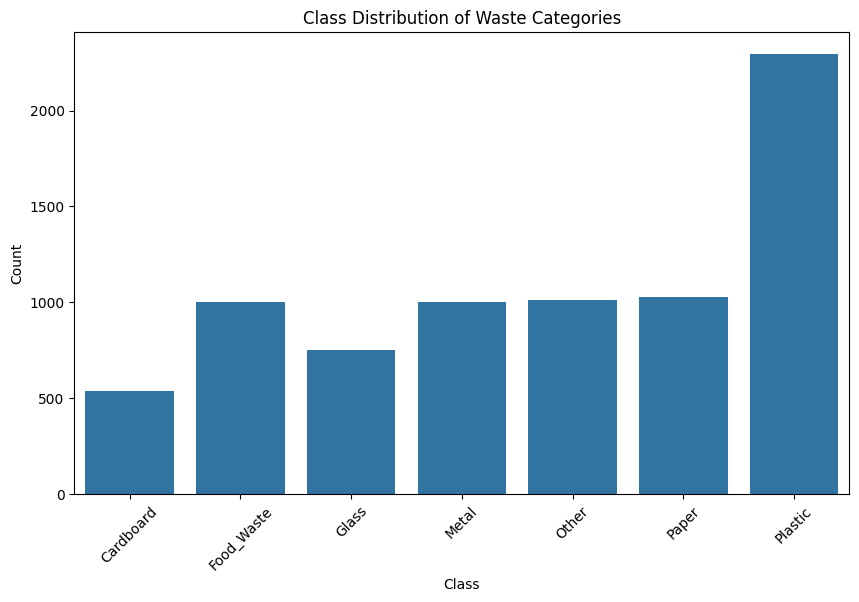

In [9]:
# Visualise Data Distribution
# Count samples per class

class_counts = pd.Series(y).value_counts().sort_index()

# Map indices to class names
class_labels = [class_names[i] for i in class_counts.index]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=class_labels, y=class_counts.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution of Waste Categories')
plt.xticks(rotation=45)

In [10]:
# Show percentage distribution
class_percent = (class_counts / class_counts.sum()) * 100
print(class_percent)

0     7.081967
1    13.114754
2     9.836066
3    13.114754
4    13.245902
5    13.508197
6    30.098361
Name: count, dtype: float64


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

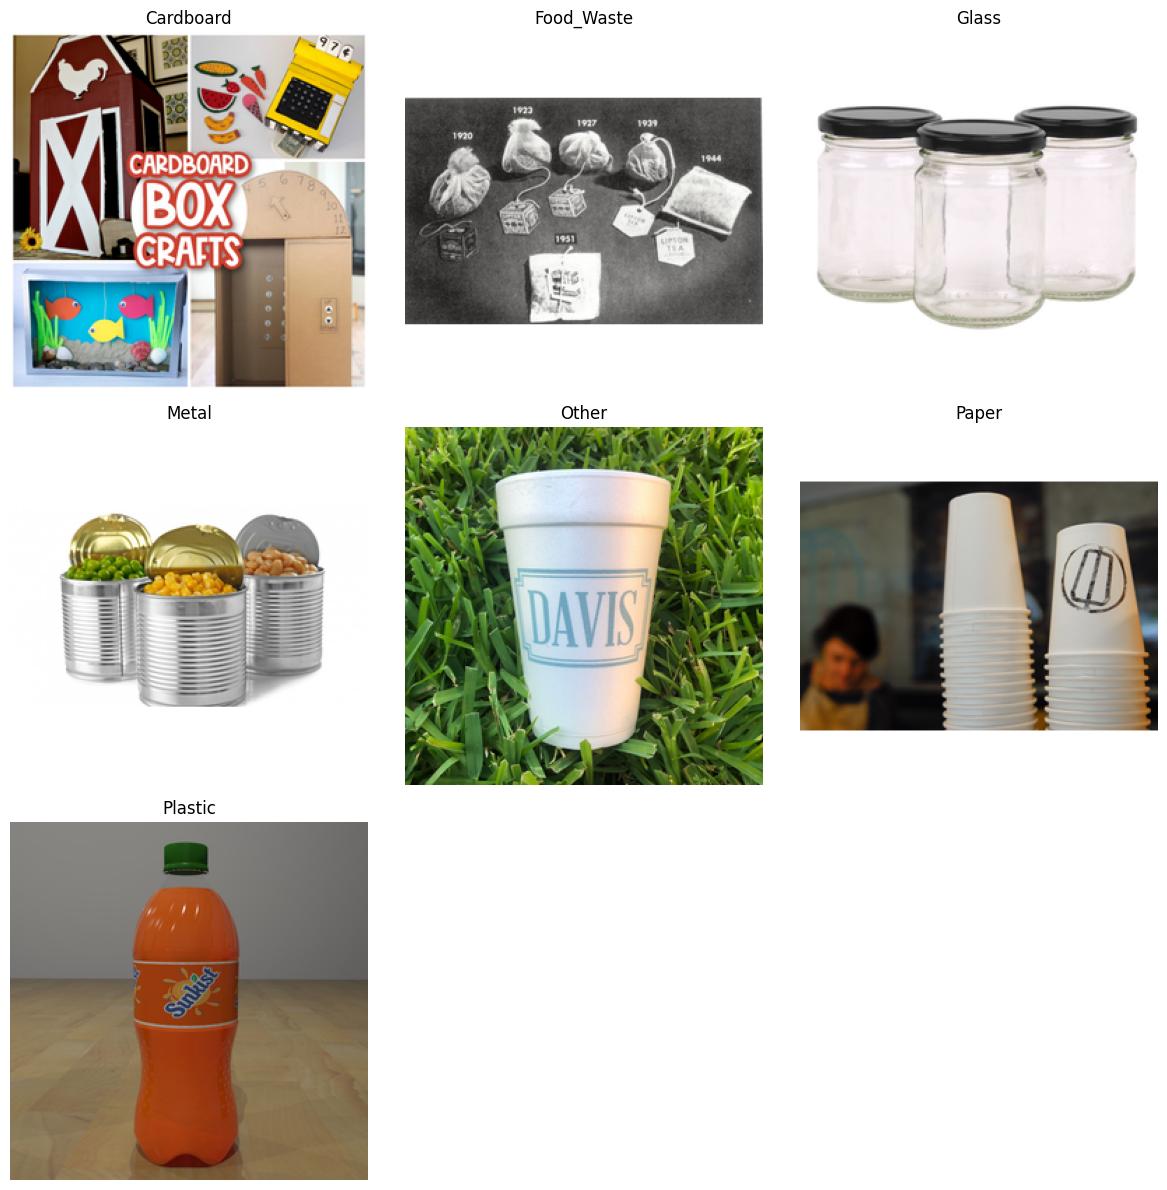

In [11]:
# Visualise Sample Images (across different labels)
plt.figure(figsize=(12, 12))

for class_idx in range(len(class_names)):
    indices = np.where(y == class_idx)[0]

    # Random image from each class
    img_index = np.random.choice(indices)

    plt.subplot(3, 3, class_idx + 1)
    plt.imshow(X[img_index])
    plt.title(class_names[class_idx])
    plt.axis("off")

plt.tight_layout()
plt.show()

#“During EDA, I found some noisy or irrelevant images in certain classes,
# which can negatively impact model performance.
# This indicates real-world dataset imperfections.”

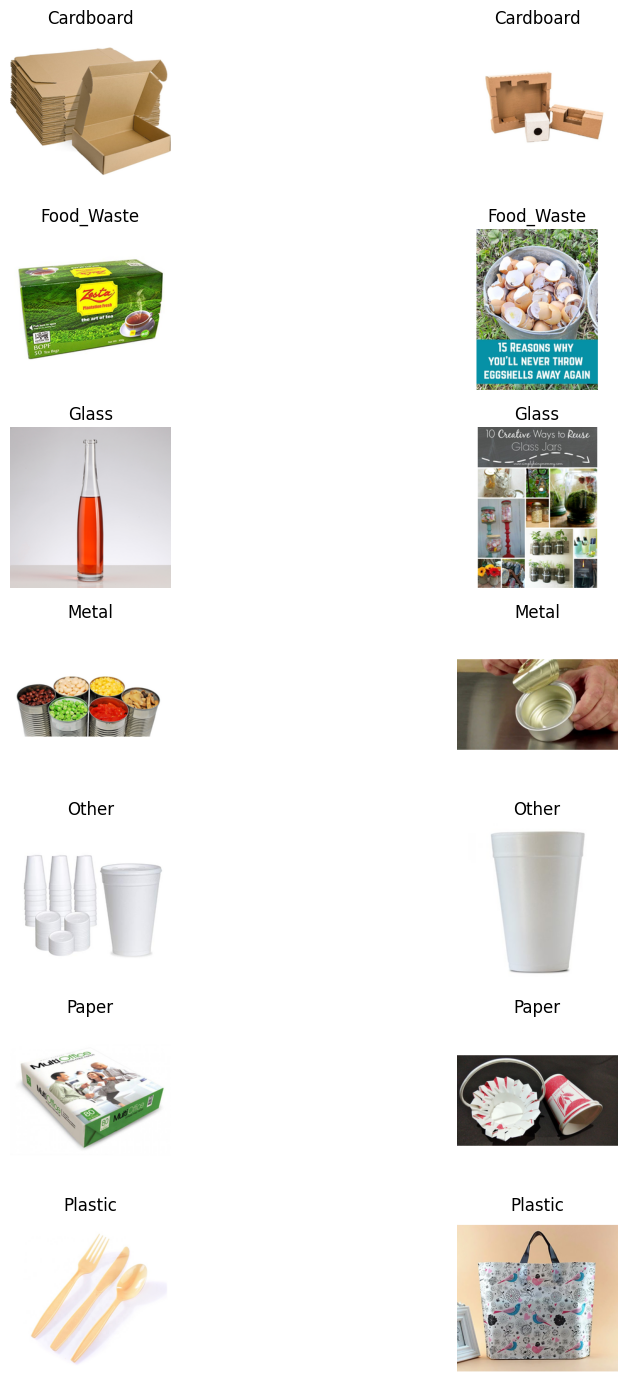

In [14]:
samples_per_class = 2

plt.figure(figsize=(12, 14))
plot_idx = 1

for class_idx in range(len(class_names)):
    indices = np.where(y == class_idx)[0]

    for i in range(samples_per_class):
        img_index = np.random.choice(indices)

        plt.subplot(len(class_names), samples_per_class, plot_idx)
        plt.imshow(X[img_index])
        plt.title(class_names[class_idx])
        plt.axis("off")

        plot_idx += 1

plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [15]:
# Find the smallest and largest image dimensions from the data set


min_width, min_height = float('inf'), float('inf')
max_width, max_height = 0, 0

for img in X:
    height, width, _ = img.shape

    min_width = min(min_width, width)
    min_height = min(min_height, height)

    max_width = max(max_width, width)
    max_height = max(max_height, height)

print(f"Smallest Image Size: ({min_width}, {min_height})")
print(f"Largest Image Size: ({max_width}, {max_height})")


Smallest Image Size: (256, 256)
Largest Image Size: (256, 256)


In [16]:
# I find all the images are already uniform Height = 256, Width = 256 and Channels = 3(RGB)
for i in range(5):
    img = PIL.Image.open(os.path.join(data_dir, class_names[0], os.listdir(os.path.join(data_dir, class_names[0]))[i]))
    print(img.size)  # (width, height)

unique_shapes = set()

for img in X:
    unique_shapes.add(img.shape)

print("Unique shapes:", unique_shapes)

(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
Unique shapes: {(256, 256, 3)}


In [17]:
# Resize the image dimensions

# Although all images are already of size 256x256,
# we resize them to 224x224 for compatibility with standard CNN architectures
# and to reduce computational cost.

X_resized = []

for img in X:
    img_pil = PIL.Image.fromarray(img)
    img_resized = img_pil.resize((224, 224))
    X_resized.append(np.array(img_resized))

X_resized = np.array(X_resized)
X_resized.shape

(7625, 224, 224, 3)

### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [18]:
# Encode the labels suitably

# Encode labels (already done via label_map)
y_encoded = np.array(labels)

print("Encoded labels shape:", y_encoded.shape)
print("Sample labels:", y_encoded[:10])

# The labels are already integer encoded using label_map.
# Hence, no further transformation like one-hot encoding is required.
# We will use sparse_categorical_crossentropy during model training.



Encoded labels shape: (7625,)
Sample labels: [0 0 0 0 0 0 0 0 0 0]


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [19]:
# Assign specified parts of the dataset to train and validation sets
# Split data, 80% training and 20% validation

X_train, X_val, y_train, y_val = train_test_split(X_resized, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (6100, 224, 224, 3)
X_val shape: (1525, 224, 224, 3)
y_train shape: (6100,)
y_val shape: (1525,)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [20]:
# Build and compile the model
num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Flatten and Fully Connected
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the architecture
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818,311 (98.49 MB)

 Trainable params: 25,817,863 (98.49 MB)

 Non-trainable params: 448 (1.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [21]:
# Training
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_val, y_val), batch_size=32)


Epoch 1/10
137/191 ━━━━━━━━━━━━━━━━━━━━ 5:23 6s/step - accuracy: 0.2079 - loss: 10.7804

KeyboardInterrupt: 

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

In [ ]:
# Evaluate on the test set; display suitable metrics



## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results